In [1]:
import joblib
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/titanic.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (891, 12)


In [3]:
# --- 2. Genel Yapı, Tipler ve Eksik Veri Analizi ---
check_general_structure(df)

=== Veri Tipleri ve Non-Null Bilgisi ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

=== Eksik Değer Özeti ===
          Eksik Sayısı  Eksik Oranı (%)
Age                177        19.865320
Cabin              687        77.104377
Embarked             2         0.224467


,Eksik Sayısı,Eksik Oranı (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [4]:
# Unvanları Ayıklama
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = [
    "Capt",
    "Col",
    "Don",
    "Dr",
    "Major",
    "Rev",
    "Jonkheer",
    "Dona",
    "Lady",
    "Countess",
    "Sir",
]
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

In [5]:
# Yaş Kısmınıdaki Boş Değerleri Median ile Doldurma
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))

In [6]:
# Embarked Eksik Değerlerini Doldurma
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [7]:
# Kabin sütununun ilk harfini al, boş olanları 'U' (Unknown) yap
df["Cabin_Deck"] = df["Cabin"].str[0].fillna("U")

# Orijinal Cabin sütununu artık düşebiliriz
df = df.drop(columns=["Cabin","Name","Ticket"])

In [9]:
numeric_cols = df.select_dtypes(include=["number"]).drop(columns="PassengerId")
categorical_cols = df.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

--- Sayısal Sütun Dağılımları ---


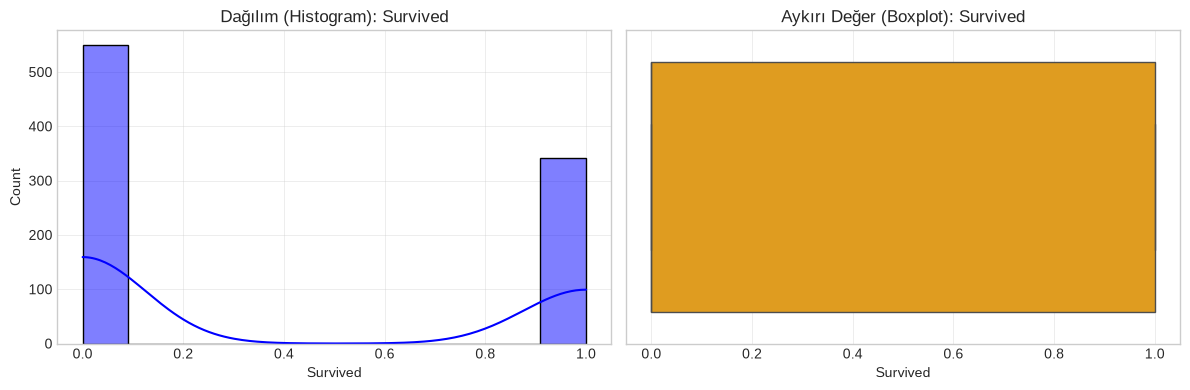

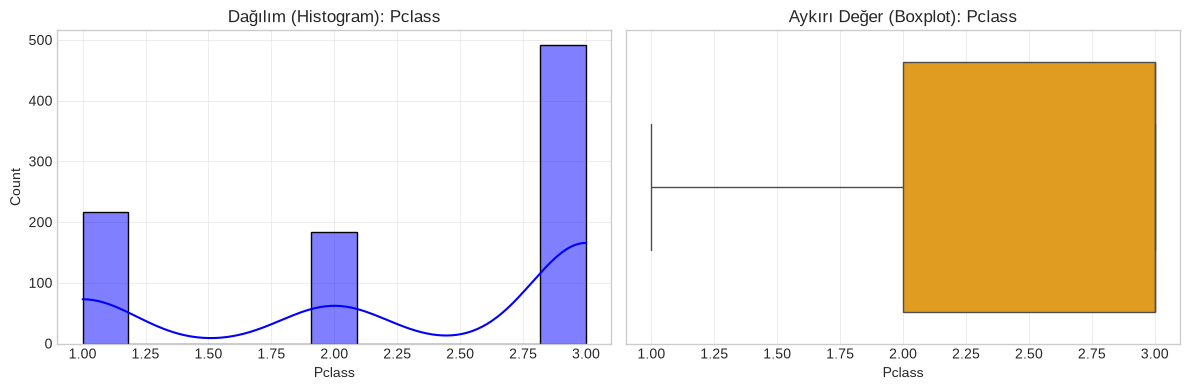

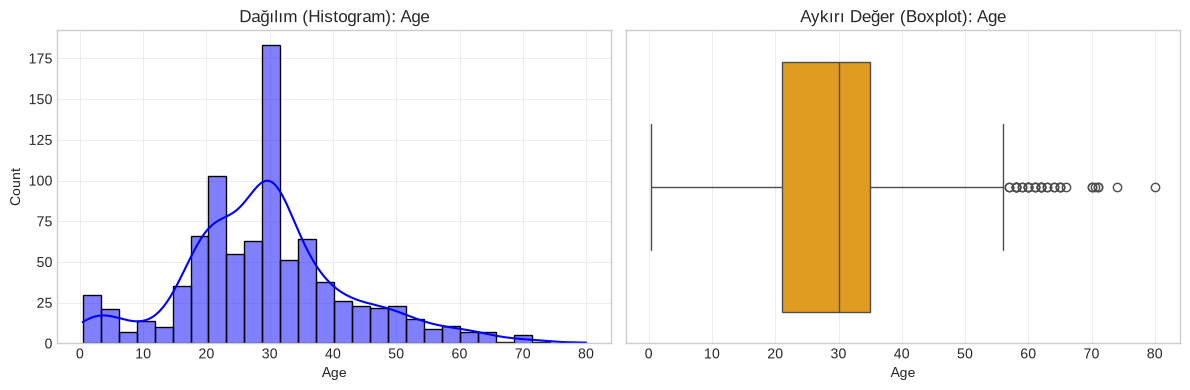

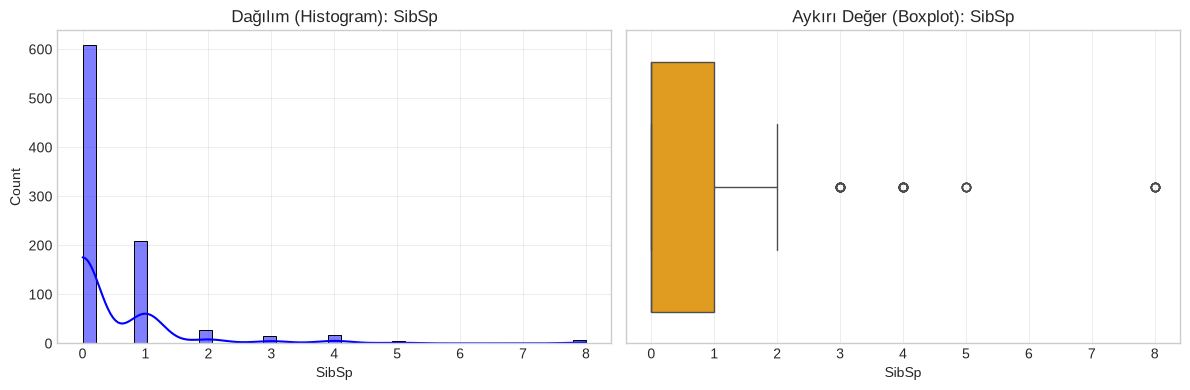

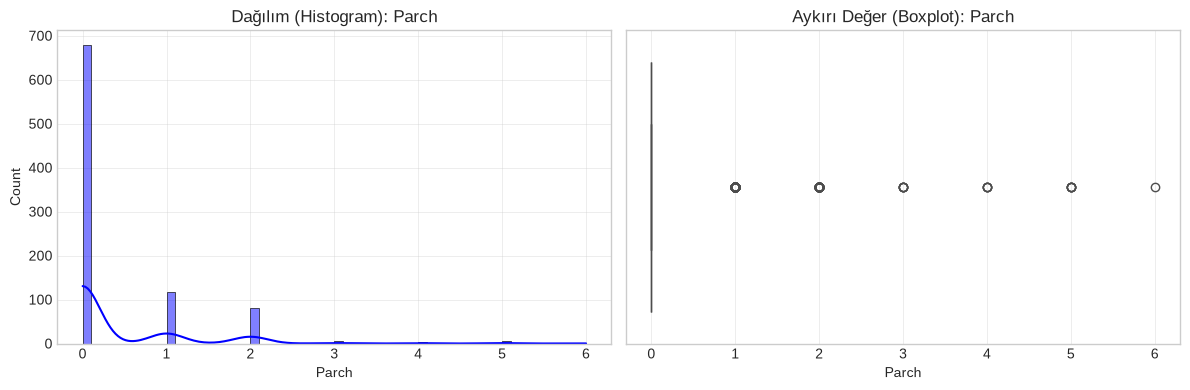

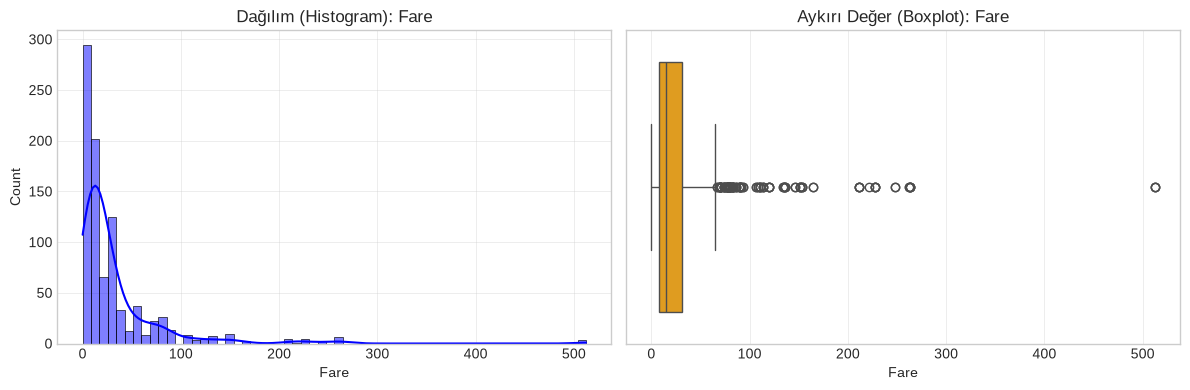

In [10]:
# Sayısal dağılımları çiz
print("--- Sayısal Sütun Dağılımları ---")
plot_statistical_distributions(df, numeric_cols)

--- Kategorik Sütun Dağılımları ---


/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:315: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

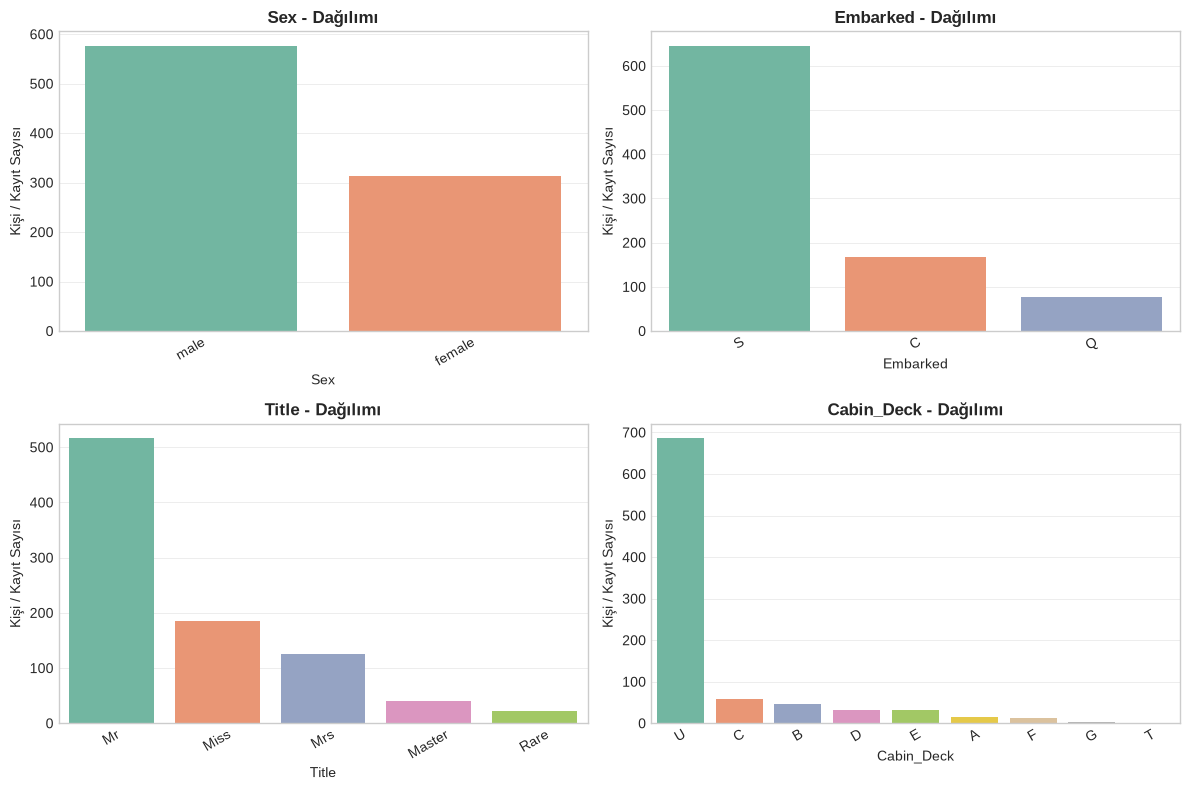

In [11]:
# Kategorik (String) dağılımları çiz
print("--- Kategorik Sütun Dağılımları ---")
plot_categorical_distributions(df, categorical_cols)

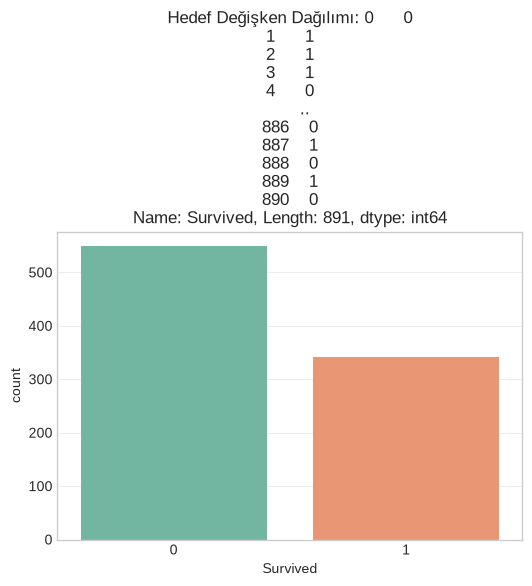

In [12]:
# --- 3. Hedef Değişken (Target) Dağılımı ---
target_column = df["Survived"]
plot_target_distribution(df, target_column)

Tespit edilen sayısal sütunlar: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Tespit edilen kategorik (string) sütunlar: ['Sex', 'Embarked', 'Title', 'Cabin_Deck']
--- İstatistiksel Öznitelik Önem Analizi (Mutual Information) ---
         Feature  MI_Score
10      Title_Mr  0.157029
6       Sex_male  0.154630
5           Fare  0.117255
11     Title_Mrs  0.068968
1         Pclass  0.068548
20  Cabin_Deck_U  0.060941
9     Title_Miss  0.060307
3          SibSp  0.044085
2            Age  0.034029
14  Cabin_Deck_C  0.023576
4          Parch  0.021345
0    PassengerId  0.018156
13  Cabin_Deck_B  0.017983
8     Embarked_S  0.017388
15  Cabin_Deck_D  0.010701
16  Cabin_Deck_E  0.005994
12    Title_Rare  0.002196
7     Embarked_Q  0.000000
17  Cabin_Deck_F  0.000000
18  Cabin_Deck_G  0.000000
19  Cabin_Deck_T  0.000000


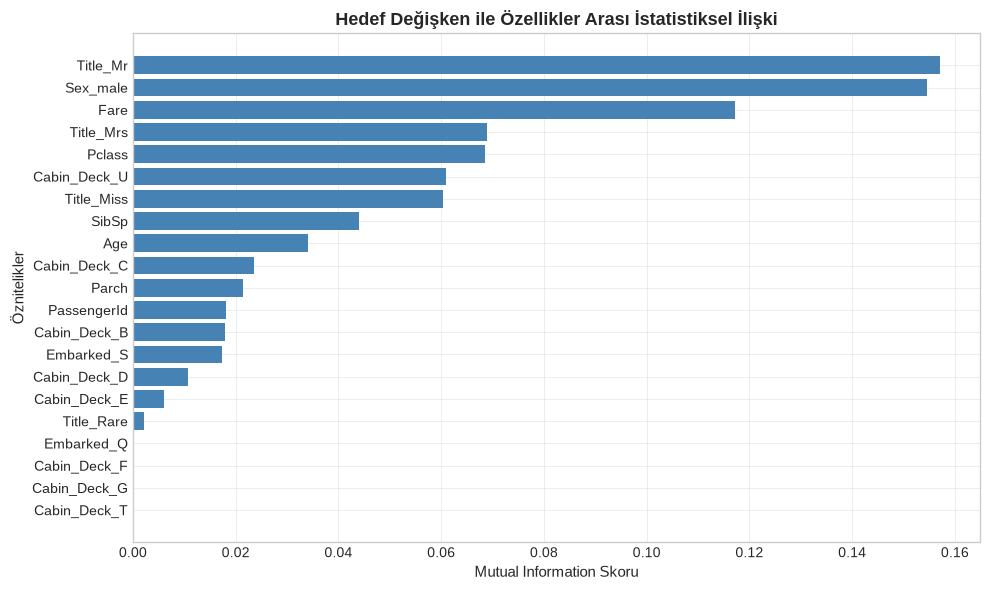

In [13]:
# --- 4. İstatistiksel İlişki Analizi (Mutual Information) ---
mi_results = calculate_and_plot_mutual_information(df, target_col="Survived")

In [14]:
target_corr, to_drop = analyze_mixed_feature_relations(df, target_col="Survived")

Tespit edilen sayısal sütunlar: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Tespit edilen kategorik (string) sütunlar: ['Sex', 'Embarked', 'Title', 'Cabin_Deck']
--- Karma/Kategorik Özellik İlişki Skorları (Mutual Information) ---
Title_Mr        0.157029
Sex_male        0.154630
Fare            0.117255
Title_Mrs       0.068968
Pclass          0.068548
Cabin_Deck_U    0.060941
Title_Miss      0.060307
SibSp           0.044085
Age             0.034029
Cabin_Deck_C    0.023576
Parch           0.021345
PassengerId     0.018156
Cabin_Deck_B    0.017983
Embarked_S      0.017388
Cabin_Deck_D    0.010701
Cabin_Deck_E    0.005994
Title_Rare      0.002196
Embarked_Q      0.000000
Cabin_Deck_F    0.000000
Cabin_Deck_G    0.000000
Cabin_Deck_T    0.000000
dtype: float64
Düşürülebilecek Düşük Skorlu Sütunlar: ['Cabin_Deck_E', 'Title_Rare', 'Embarked_Q', 'Cabin_Deck_F', 'Cabin_Deck_G', 'Cabin_Deck_T']


In [15]:
# --- 5. Verinin Eğitim ve Test Olarak Ayrılması ---
X = df.drop(columns=["Survived"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Veri Bölündü -> Train: (712, 10), Test: (179, 10)


In [16]:
# --- 6. Outlier Değerleri Belirleme ---
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train, X_test, numeric_cols)

=== Aykırı Değer (Outlier) Sayıları ===
🔸 Age: 20 adet aykırı değer bulundu.
🔸 SibSp: 33 adet aykırı değer bulundu.
🔸 Parch: 170 adet aykırı değer bulundu.
🔸 Fare: 91 adet aykırı değer bulundu.
8. IQR Clipping İşlemi Tamamlandı (Faktör: 1.5).


In [17]:
# --- 7. Correlation Filtresi (Clipping Sonrasında) ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_clipped, X_test_clipped, corr_threshold=0.5
)

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 9


In [18]:
# --- Sabit (Constant) Sütunları Temizleme ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() <= 1]

if constant_cols:
    print(f"Sabit sütunlar tespit edildi ve çıkarılıyor: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("Sabit sütun bulunamadı.")

Sabit sütunlar tespit edildi ve çıkarılıyor: ['Parch']


In [19]:
# --- 8. Öznitelik Seçimi (Feature Selection) ---
selected_features = select_best_features_anova_string(X_train_corr, y_train)

# Liste içindeki None veya NaN değerleri temizleyelim
selected_features = [
    f for f in selected_features if f is not None and pd.notna(f)
]

X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== En İyi 5 Özellik (ANOVA) ===
         Feature       Score
8       Title_Mr  317.016763
4       Sex_male  306.593249
18  Cabin_Deck_U   99.462219
1         Pclass   97.835853
9      Title_Mrs   97.430906


KeyError: "['Title_Mr', 'Sex_male', 'Cabin_Deck_U', 'Title_Mrs'] not in index"

In [ ]:
# Hepsini tek bir pakette topla
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Tek dosyaya kaydet
joblib.dump(bundle, "../backend/models/titanic/titanic_data_bundle.pkl")
print(
    "İşlenmiş drug veri setleri başarıyla backend/models/titanic/"
    " klasörüne kaydedildi!"
)